# Project Title: HEALTHCARE DATA QUALITY & PATIENT PROFILE ANALYSIS
### An Exploratory Data Analysis using Python and Pandas

**Author:** Benjamin Christiana  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Date:** July 2026

## Project overview
This Project analyzes healthcare data to evaluate data quality, population characteristics, hospital utilization and readmission.
The analysis was conducted using Python, with Pandas used for data
manipulation and Matplotlib and Seaborn used for data visualization.


## Business problem
The hospital's historical diabetes patient encounter dataset contains potential data quality and consistency issues that may affect the reliability of healthcare analytics and future predictive modelling. The hospital needs a systematic assessment of the dataset to identify data quality problems, understand the characteristics of the patient population, and uncover initial patterns in hospital utilization and readmission.

## Project Objectives
### Objective 1 — Understand the Dataset
Determine:
Number of rows
Number of columns
Data types
Meaning of each variable
Numerical vs categorical variables

### Objective 2 — Assess Data Quality
Identify:
Missing values
Duplicate records
Inconsistent categorical values
Placeholder values representing missing data
Potential invalid values
Data type issues

### Objective 3 — Clean the Dataset
Where appropriate:
Standardize column names
Handle missing values
Remove or investigate duplicates
Standardize categorical variables
Convert data types
Document every cleaning decision
### Objective 4 — Understand the Patient Population
Analyze:
Age distribution
Gender distribution
Race distribution
Medical specialty
Patient encounter patterns

### Objective 5 — Explore Hospital Utilization
Investigate:
Length of hospital stay
Number of medications
Number of procedures

### Objective 6 — Explore Readmission
Investigate:
Overall readmission patterns
Differences between readmitted and non-readmitted patients
Potential factors associated with readmission

### Objective 7 — Generate Healthcare Insights
Translate your findings into:
Key findings
Data quality recommendations
Healthcare/business recommendations
Suggestions for future analysis


## Dataset Description

Diabetes 130-US Hospitals for Years 1999–2008.

The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, received medications, and stayed up to 14 days. 

Key Variables used in this analysis include
- encounter_id: Unique identifier of an encounter
- patient_nbr: Unique identifier of a patient
- race: Values: Caucasian, Asian, African American, Hispanic, and other
- gender : Values: male, female, and unknown/invalid
- age: Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)
- weight: Weight in pounds.
- admission_type_id: Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available
- discharge_disposition_id: Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available
- admission_source_id: Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital
- time_in_hospital: Integer number of days between admission and discharge
- medical_specialty: Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon
- diag_1: The primary diagnosis (coded as first three digits of ICD9); 848 distinct values
- diag_2: Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values
- diag_3: Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values
- number_diagnoses: Number of diagnoses entered to the system
- change: Indicates if there was a change in diabetic medications (either dosage or generic name). Values: change and no change
- diabetesMed : Indicates if there was any diabetic medication prescribed. Values: yes and no
- readmitted: 	Days to inpatient readmission. Values: <30 if the patient was readmitted in less than 30 days, >30 if the patient was readmitted in more than 30 days, and No for no record of readmission.

Source: Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, “Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,” BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.

https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

## Tools and Libraries
- **Pandas:** Data manipulation and analysis.
- **NumPy:** Numerical operations.
- **Matplotlib:** Data visualization.
- **Seaborn:** Statistical data visualization.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading and Understanding

In [2]:
path = r"C:\Users\USER\Downloads\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv"

df = (
    pd.read_csv(path)
)
print(df.head())
print(df.shape)
print(df.info())
print(df.dtypes)
print(df.isnull().sum())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

The dataset loads correctly.
### Data set shape
It contains 101766 rows of patient data and 50 variables.
### Missing Values
Missing values were assessed across all variables using the `isnull().sum()` method.
- The assessment identified missing values in the `number_diagnoses` with 96420 null values and `A1Cresult` with 84748 null values;
### Data types
The age and weight column dtype is object, this will be further investigated 

In [3]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Data Understanding
Checking for duplicates values

In [4]:
print(df.duplicated().any())
print(df['patient_nbr'].duplicated().any())
print(df['patient_nbr'].duplicated().sum())

False
True
30248


Checking for unique values in the id columns

In [5]:
print(df["patient_nbr"].value_counts().head(10))
print(df.shape)
print(df["patient_nbr"].nunique())
print(df["encounter_id"].nunique())

patient_nbr
88785891    40
43140906    28
1660293     23
88227540    23
23199021    23
23643405    22
84428613    22
92709351    21
88789707    20
29903877    20
Name: count, dtype: int64
(101766, 50)
71518
101766


"The dataset contains no exact duplicate rows. However, `the patient_nbr` column contains repeated patient identifiers, while encounter_id contains unique values. This indicates that some patients have multiple hospital encounters. These records will be retained because each encounter may contain distinct healthcare information relevant to the analysis."

One row = one hospital encounter

## Data Cleaning
Addressing incorrect data types, missing values, and impossible values

In [6]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
print('race:',df['race'].unique())
print('gender:' ,df['gender'].unique())
print('age:' ,df['age'].unique())
print('weight: ',df['weight'].unique())
print('time in hospital: ',df['time_in_hospital'].unique())
print('payer code: ' ,df['payer_code'].unique())
print('max glu serum: ',df['max_glu_serum'].unique())
print('A1Cresult: ',df['A1Cresult'].unique())
print('readmitted: ',df['readmitted'].unique())

race: ['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']
gender: ['Female' 'Male' 'Unknown/Invalid']
age: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
weight:  ['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']
time in hospital:  [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
payer code:  ['?' 'MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
max glu serum:  [nan '>300' 'Norm' '>200']
A1Cresult:  [nan '>7' '>8' 'Norm']
readmitted:  ['NO' '>30' '<30']


Across multiple columns null values are entered as *?*, this will be corrected to allow for uniformity

In [8]:
df =df.replace('?', pd.NA)
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

After replacing the placeholder(?) with missing values, there are a lot more missing values in the dataset, these will be further investigated to understand how best to handle them, also considering their relevance to the analysis objective.

#### Race

In [9]:
df['race']=df['race'].fillna("Unknown")

There are 2273 Missing values in the `race` column, the missing values is replaced with "Unknown"

#### Gender

In [10]:
print(df['gender'].nunique())
print(df['gender'].value_counts(dropna=False))
df['gender']=df['gender'].replace('Unknown/Invalid', 'Unknown')
print(df['gender'].value_counts(dropna=False))

3
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
gender
Female     54708
Male       47055
Unknown        3
Name: count, dtype: int64


There are 3 Unknown/Invalid rows in the `gender` column, they are replaced with 'Unknown

#### Weight

In [11]:
df= df.drop(columns = "weight")

Over 90% (98,569 observations) of the `weight` column were missing. Because imputing such a large proportion of missing values would introduce substantial bias, and the variable is not central to the objectives of this analysis, the column was removed.

#### Diagnosis

In [12]:
diag_col =['diag_1','diag_2','diag_3']
df[diag_col]=df[diag_col].fillna("Unknown")

The missing values in the **diagnosis** columns were filled with Unknown

#### Other columns

In [13]:
df=df.drop(columns =['max_glu_serum','A1Cresult','medical_specialty','payer_code'])

The above columns: `max_glu_serum`,`A1Cresult`,`medical_specialty`,`payer_code` were dropped because of the large amount of missing values, and they are not relevant to the analysis

#### Post cleaning validation

In [14]:
print(df.head())
print(df.shape)
print(df.info)
df.isnull().sum()

   encounter_id  patient_nbr             race  gender      age  \
0       2278392      8222157        Caucasian  Female   [0-10)   
1        149190     55629189        Caucasian  Female  [10-20)   
2         64410     86047875  AfricanAmerican  Female  [20-30)   
3        500364     82442376        Caucasian    Male  [30-40)   
4         16680     42519267        Caucasian    Male  [40-50)   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  num_lab_procedures  ...  citoglipton  insulin  \
0                 1                  41  ...           No       No   
1                 3                 

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide

The dataset is now clean and ready for Exploratory Data Analysis

## Exploratory Data Analysis(EDA)

#### PATIENT DEMOGRAPHIC

#### Gender

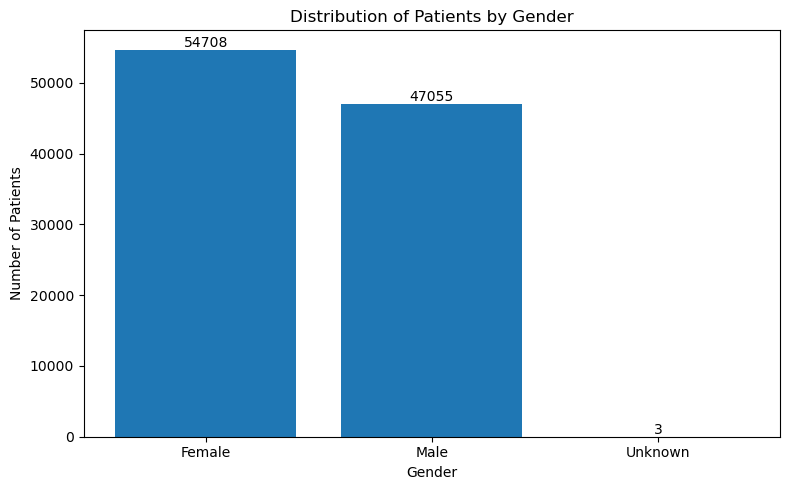

In [104]:
gender_count=df['gender'].value_counts()
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(gender_count.index, gender_count.values)
ax.bar_label(bars)
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Patients by Gender')
plt.tight_layout()
plt.show()

The dataset shows a relatively balanced distribution by gender, with female encounters accounting for **52.5%** and male encounters accounting for **47.5%**. Less than 1% of encounters have an unknown gender.

#### Age

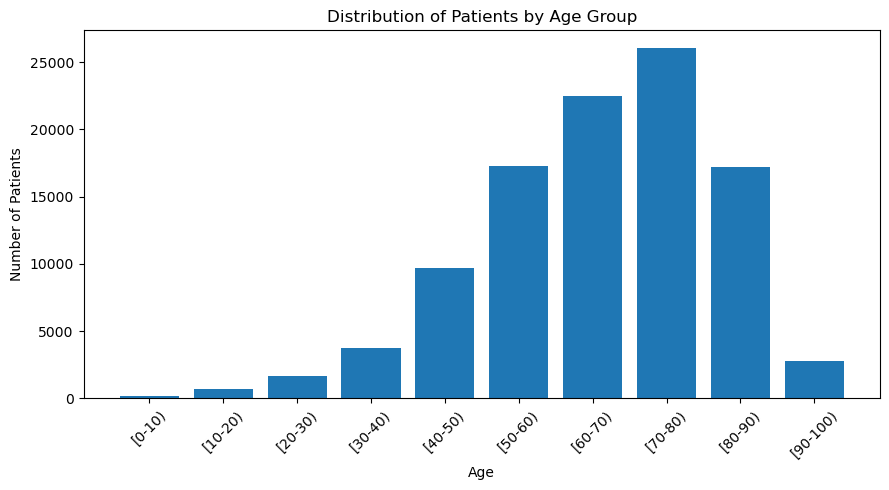

In [102]:
age_count = df['age'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(age_count.index, age_count.values)
ax.set_xlabel("Age")
ax.set_ylabel('Number of Patients')
ax.set_title("Distribution of Patients by Age Group")
ax.tick_params(axis ='x', labelrotation= 45)
plt.tight_layout()
plt.show()

Most encounters were recorded among patients aged **50 years and above**, with the 70–80 age group having the highest number of encounters (26,068). Younger age groups were considerably less represented, particularly those aged 0–10 years (161 encounters).

#### Race

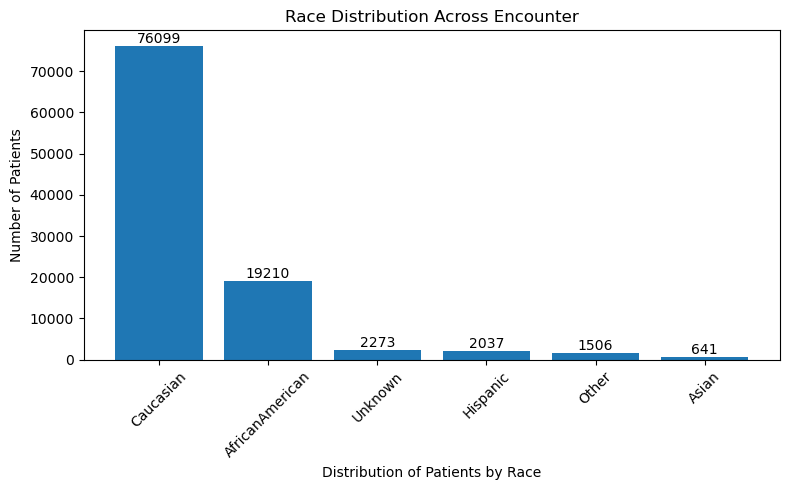

In [100]:
fig, ax= plt.subplots(figsize=(9,5))
race_count=df['race'].value_counts()
race_bar=ax.bar(race_count.index,race_count.values)
ax.bar_label(race_bar)
ax.set_xlabel('Distribution of Patients by Race')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', labelrotation =45)
ax.set_title('Race Distribution Across Encounter')
plt.tight_layout()
plt.show()

The dataset is predominantly composed of encounters involving **Caucasian patients**, who account for approximately 74.8% of all encounters. **AfricanAmerican** patients represent approximately 18.9%, while **Hispanic**, **Asian**, and Other racial groups each account for less than 3%. About 2.2% of encounters have an **unknown** race.

#### HOSPITAL UTILIZATION

#### Length of Hospital stay

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


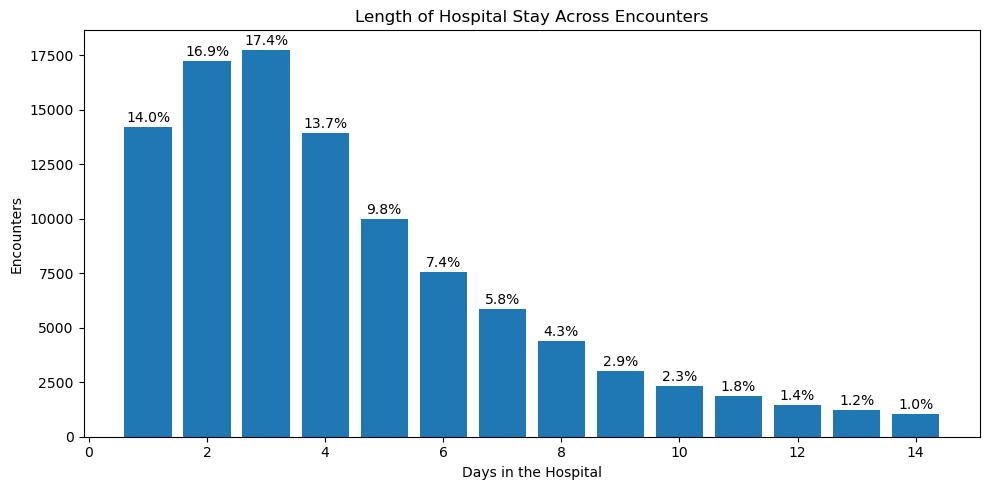

In [98]:
print(df['time_in_hospital'].describe())
stay_counts=df['time_in_hospital'].value_counts()
fig, ax = plt.subplots(figsize=(10,5))
stay_bar=ax.bar(stay_counts.index, stay_counts.values)

labels = [f"{x / stay_counts.sum():.1%}" for x in stay_counts.values]

ax.bar_label(stay_bar, labels=labels, padding =1.5)
ax.set_xlabel('Days in the Hospital')
ax.set_ylabel('Encounters')
ax.set_title('Length of Hospital Stay Across Encounters')
plt.tight_layout()
plt.show()

**Interpretation**
- The average length of hospital stay was approximately 4.4 days, with a median of 4 days. Half of the encounters lasted between 2 and 6 days, while the overall length of stay ranged from 1 to 14 days. The relatively small difference between the mean and median suggests that the distribution is reasonably centered, although some longer hospital stays may be influencing the average.
- Most encounters involved relatively short hospital stays. This pattern may reflect routine stabilization and discharge practices, although additional analysis would be required to determine the factors associated with length of stay.

#### Laboratory Procedures

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64


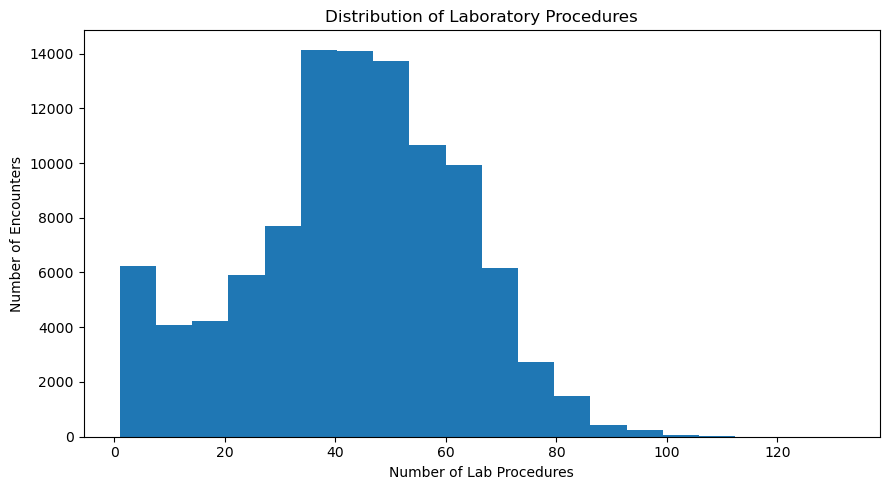

In [97]:
print(df['num_lab_procedures'].describe())

fig,ax = plt.subplots(figsize = (9,5))
ax.hist(df['num_lab_procedures'], bins=20)

ax.set_xlabel("Number of Lab Procedures")
ax.set_ylabel("Number of Encounters")
ax.set_title("Distribution of Laboratory Procedures")
plt.tight_layout()

plt.show()

The number of laboratory procedures per encounter was concentrated mainly between 30 and 60 procedures, with the highest frequency occurring around 35–45 procedures. The distribution is right-skewed, with the number of encounters decreasing as the number of procedures increases. Encounters involving more than 80 laboratory procedures were relatively uncommon, while a smaller group of encounters involved very few procedures.

#### Diabetic medications

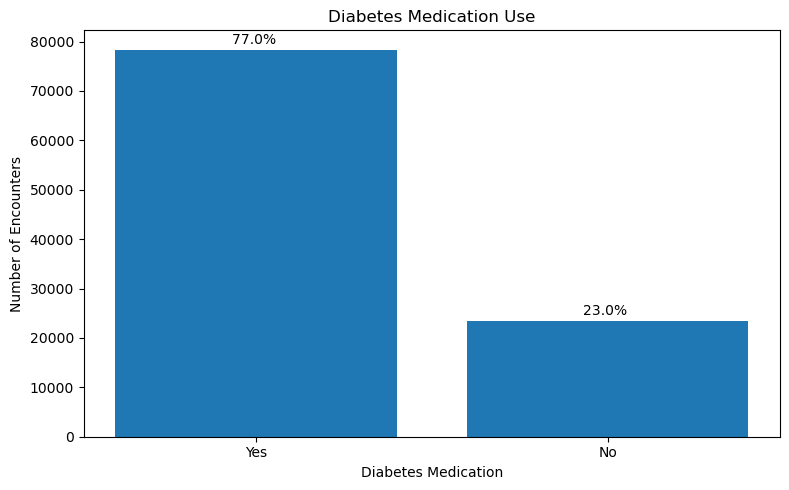

In [95]:
med_count= df["diabetesMed"].value_counts()
med_percent = med_count/med_count.sum() * 100

fig, ax = plt.subplots(figsize=(8,5))
med_bar =ax.bar(med_count.index, med_count.values)
label=[f"{x:.1f}% " for x in med_percent.values]
ax.bar_label(med_bar, labels = label, padding =2)
ax.set_xlabel("Diabetes Medication")
ax.set_ylabel("Number of Encounters")
ax.set_title("Diabetes Medication Use")
plt.tight_layout()

plt.show()


Diabetic medication was prescribed in 77.0% of the hospital encounters, while 23.0% had no recorded diabetic medication prescription. This indicates that medication management was common across the encounters, although a substantial proportion had no diabetic medication recorded during the hospitalization

#### Medications administered

metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64


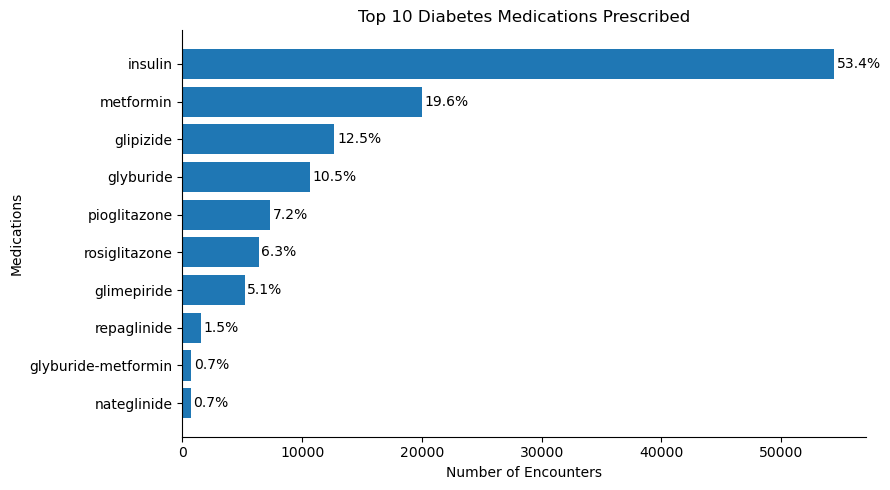

In [94]:
print(df['metformin'].value_counts())
# Assigning all the medications administered to one variable
medications = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

# The number of times each medication was prescribed
med_count ={
    medication:df[medication].isin(["Steady", "Up", "Down"]).sum()
    for medication in medication_cols
    }
med_count=pd.Series(med_count)

# Selecting the top ten medications prescribed
top10= med_count.sort_values(ascending = False).head(10)
top10_percent = top10 / len(df) * 100

# Visualization
fig, ax = plt.subplots(figsize=(9,5))
barh=ax.barh(top10.index, top10.values)
labels = [f"{x:.1f}%" for x in top10_percent]
ax.bar_label(barh, labels=labels, padding=2)
ax.invert_yaxis()
ax.margins(y=0.05)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel('Number of Encounters')
ax.set_ylabel("Medications")
ax.set_title("Top 10 Diabetes Medications Prescribed")
plt.tight_layout()
plt.show()


**Insulin** was the most frequently prescribed diabetes medication, being administered during over half of all hospital encounters (53.4%). Metformin was the second most commonly prescribed medication (19.6%), followed by Glipizide (12.5%) and Glyburide (10.5%). Most of the remaining medications were prescribed relatively infrequently, while Examide and Citoglipton were not prescribed in any encounter.

### Readmission( Patient Outcome)

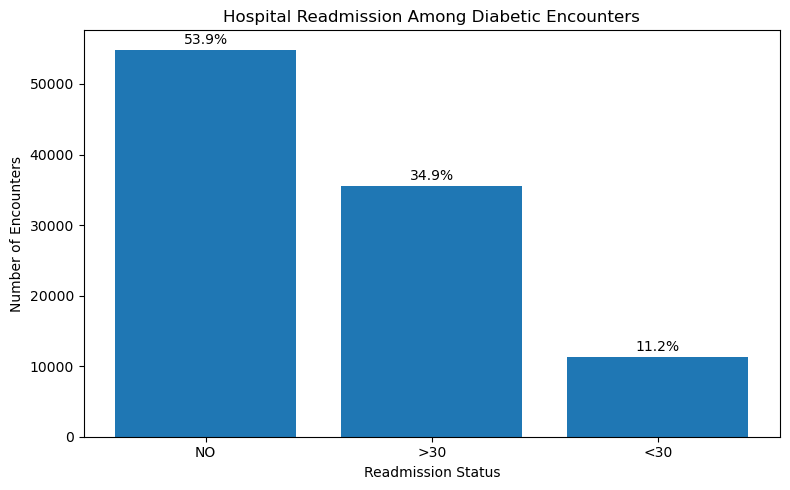

In [92]:
readmit_count=(df['readmitted'].value_counts())
readmit_percent=df['readmitted'].value_counts(normalize= True).mul(100)

# Reorder the categories for a more logical presentation
readmit_count=readmit_count.reindex(["NO", ">30", "<30"])

fig,ax =plt.subplots(figsize=(8,5))
bars= ax.bar(readmit_count.index, readmit_count.values)
labels= [f"{x:.1f}%" for x in readmit_percent]
ax.bar_label (bars, labels=labels, padding =2)
ax.set_xlabel("Readmission Status")
ax.set_ylabel("Number of Encounters")
ax.set_title("Hospital Readmission Among Diabetic Encounters")
plt.tight_layout()

plt.show()

More than half **(53.9%)** of the diabetic hospital encounters had no recorded readmission. However, **46.1%** resulted in readmission, with 34.9% occurring after 30 days and 11.2% occurring within 30 days. Although early readmissions were less frequent, the overall proportion of readmitted encounters suggests that hospital readmission is an important outcome to investigate further in this patient population.

#### Readmission by age group

In [57]:
readmit_age_percent = pd.crosstab(df["age"],df["readmitted"],normalize='index').mul(100)
readmit_age

readmitted,<30,>30,NO
age,,,
[0-10),1.863354,16.149068,81.987578
[10-20),5.788712,32.416787,61.794501
[20-30),14.242607,30.778515,54.978877
[30-40),11.231788,31.443709,57.324503
[40-50),10.604027,33.846154,55.549819
[50-60),9.666203,34.289522,56.044274
[60-70),11.128408,35.124316,53.747276
[70-80),11.773055,36.347246,51.879699
[80-90),12.083503,36.186544,51.729953


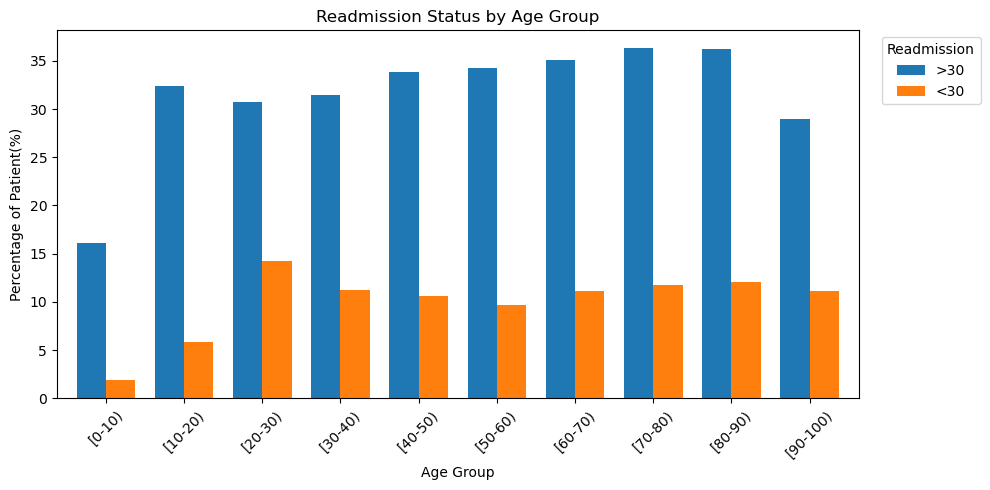

In [80]:
# Stacked bar chart
readmit_age_percent = pd.crosstab(df["age"],df["readmitted"],normalize='index').mul(100)[[">30", "<30"]]

fig, ax= plt.subplots(figsize=(10,5))

readmit_age_percent.plot(
    kind="bar",
    ax = ax,
    color = ["#1F77B4", "#FF7F0E"],
    width =0.75
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Percentage of Patient(%)")
ax.set_title("Readmission Status by Age Group")

plt.xticks(rotation=45)

ax.legend(
    title="Readmission",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


plt.tight_layout()
plt.show()

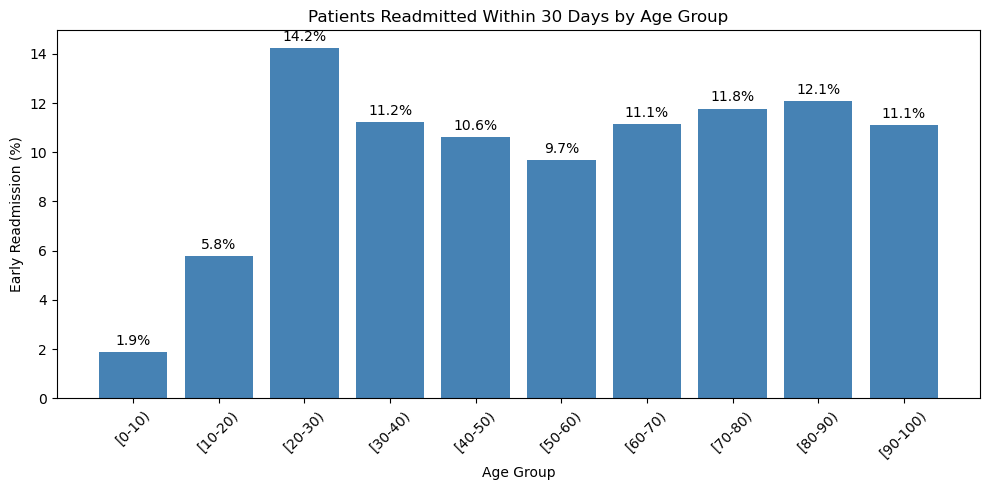

In [70]:
early_readmit = (
    pd.crosstab(df["age"], df["readmitted"], normalize="index")
    .mul(100)["<30"]
)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(
    early_readmit.index,
    early_readmit.values,
    color="steelblue"
)

labels = [f"{x:.1f}%" for x in early_readmit]

ax.bar_label(bars, labels=labels, padding=3)

ax.set_xlabel("Age Group")
ax.set_ylabel("Early Readmission (%)")
ax.set_title("Patients Readmitted Within 30 Days by Age Group")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Length of stay vs readmission

In [82]:
df.groupby('readmitted')['time_in_hospital'].describe()


,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,4.768249,3.028165,1.0,2.0,4.0,6.0,14.0
>30,35545.0,4.495541,2.988064,1.0,2.0,4.0,6.0,14.0
NO,54864.0,4.254429,2.964964,1.0,2.0,3.0,6.0,14.0


Although patients readmitted within 30 days had a slightly longer average hospital stay (4.77 days) than those not readmitted (4.25 days), the difference was relatively small. The similar quartiles and standard deviations across all groups suggest that length of stay alone is not a strong differentiating factor for hospital readmission in this dataset.

#### Medication Change vs Readmission

readmitted        <30        >30         NO
change                                     
Ch          11.822765  36.740337  51.436898
No          10.590814  33.372295  56.036892


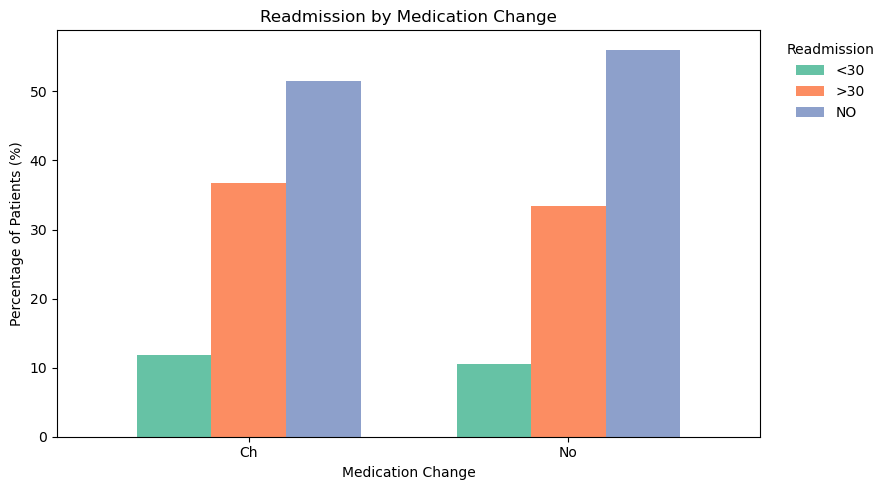

In [85]:
change_readmit = pd.crosstab(
    df["change"],
    df["readmitted"],
    normalize="index"
).mul(100)

print(change_readmit)
fig, ax = plt.subplots(figsize=(9,5))

change_readmit.plot(
    kind="bar",
    ax=ax,
    color=["#66C2A5", "#FC8D62", "#8DA0CB"],
    width=0.7
)

ax.set_xlabel("Medication Change")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_title("Readmission by Medication Change")

ax.legend(
    title="Readmission",
    frameon=False,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Interpretation

Patients whose diabetes medication was changed during their hospital stay had a slightly higher proportion of readmissions compared to patients whose medication was not changed. Specifically, 11.8% of patients with a medication change were readmitted within 30 days, compared to 10.6% among those whose medication remained unchanged. Similarly, readmission after 30 days was slightly more common among patients with medication changes (36.7%) than those without (33.4%). Conversely, patients whose medications were not changed had a higher proportion of no readmission (56.0%) compared to those whose medications were changed (51.4%).

## Key findings
- This analysis explored over 101,000 hospital encounters involving patients with diabetes to understand patient characteristics, patterns of hospital utilization, diabetes medication management, and hospital readmission outcomes.

- The analysis revealed that the majority of encounters involved older adults between 60 and 80 years of age, highlighting the significant burden of diabetes among the elderly population. Females represented a slightly larger proportion of encounters than males, while Caucasian patients accounted for the largest racial group within the dataset.

- Hospital utilization analysis showed that most patients experienced relatively short hospital stays, typically between two and six days, with an average stay of approximately 4.4 days. Although patients readmitted within 30 days had slightly longer hospital stays on average, the differences across readmission groups were modest, suggesting that length of stay alone is not a strong indicator of future readmission.

- Medication analysis showed that insulin and metformin were the most frequently prescribed diabetes medications, reflecting their central role in diabetes management. Furthermore, patients whose diabetes medications were adjusted during hospitalization experienced slightly higher readmission rates than those whose medications remained unchanged. While this association does not imply that medication changes cause readmission, it may indicate that patients requiring medication adjustments have more complex clinical conditions that warrant closer monitoring after discharge.

- More than half of all encounters (53.9%) were not followed by readmission, while 11.2% resulted in readmission within 30 days. Although this indicates that most patients did not return to the hospital shortly after discharge, the proportion of early readmissions remains clinically important because it represents patients who may benefit from improved discharge planning, medication management, and post-discharge follow-up.

Overall, the findings suggest that patient demographics alone provide limited insight into readmission risk, whereas aspects of clinical management—particularly medication adjustments—may offer more meaningful information for identifying patients who require additional care after discharge.

### Recommendation
Based on the findings of this analysis, the following recommendations are proposed:

##### 1. Prioritize high-risk patients for post-discharge interventions

Patients whose diabetes medications were adjusted during hospitalization exhibited slightly higher readmission rates. Healthcare providers should prioritize these patients for enhanced discharge planning, medication counseling, and early follow-up appointments to reduce the likelihood of avoidable readmissions.

##### 2. Implement predictive analytics for readmission risk

Healthcare institutions should develop machine learning models that incorporate demographic, clinical, medication, and hospital utilization variables to identify patients at high risk of readmission. Early identification would enable targeted interventions and more efficient allocation of healthcare resources.

##### 3. Strengthen medication management programs

Given the widespread use of insulin and metformin, hospitals should routinely review medication regimens, monitor treatment adherence, and educate patients on proper medication use before discharge to improve diabetes management outcomes.

##### 4. Expand data collection and quality improvement efforts

Several clinically relevant variables contained substantial missing data and could not be fully utilized in this analysis. Improving data completeness and standardization would support more reliable analyses and enable stronger predictive models in future studies.

##### 5. Perform deeper multivariate analysis

Future analyses should move beyond descriptive statistics by investigating how multiple factors—including age, previous hospital admissions, laboratory procedures, medication changes, and comorbidities—jointly influence readmission risk. Such analyses can uncover patterns that are not apparent from univariate exploration alone.

### Limitation
This analysis is exploratory in nature and does not establish causal relationships between patient characteristics, treatment decisions, and hospital readmission. Several variables contained substantial missing data and were excluded from the analysis to preserve data quality. In addition, the dataset represents hospital encounters rather than unique patients, meaning that some individuals appear multiple times due to repeated admissions. Consequently, the findings should be interpreted as associations observed within the available data rather than definitive evidence of causation.

### Conclusion
This project demonstrated how healthcare data can be transformed into meaningful insights through data cleaning, quality assessment, and exploratory data analysis. The findings highlighted important patterns in patient demographics, hospital utilization, diabetes medication management, and readmission outcomes, providing a clearer understanding of factors associated with diabetic hospital encounters. While the analysis identified several meaningful associations, further predictive modeling and advanced statistical analysis would be valuable for identifying patients at greatest risk of readmission and supporting more informed, data-driven clinical decision-making.

In [86]:
df.to_csv(r"C:\Users\USER\OneDrive\Documents\My files\portfolio\Python\Diabetes 130-US\diabetes_cleaned.csv", index=False)